In [1]:
import pandas as pd
from glob import glob

In [2]:
path = "../data/CICIDS2017_improved"
all_files = glob(f"{path}/*.csv")

dfs = [pd.read_csv(f) for f in all_files]
df = pd.concat(dfs, ignore_index=True)

# value check for infinite, minus infinite
df = df.replace([float("inf"), float("-inf")], float("nan"))
df = df.dropna()

In [3]:
df = df[[
            "Dst Port",
            "Protocol",
            "Flow Duration",
            "Total Fwd Packet",
            "Total Bwd packets",
            "Total Length of Fwd Packet",
            "Total Length of Bwd Packet",
            "Flow Bytes/s",
            "Flow Packets/s",
            "Fwd IAT Total",
            "Bwd IAT Total",
            "Fwd PSH Flags",
            "Fwd Header Length",
            "Bwd Header Length",
            "Fwd Packets/s",
            "Bwd Packets/s",
            "SYN Flag Count",
            "PSH Flag Count",
            "ACK Flag Count",
            "Subflow Fwd Packets",
            "Subflow Fwd Bytes",
            "Subflow Bwd Packets",
            "Subflow Bwd Bytes",
            "FWD Init Win Bytes",
            "Bwd Init Win Bytes",
            "Fwd Act Data Pkts",
            "Label"
        ]]

In [4]:
# minus value check
for col in df.columns:
    if col == "Label":
        continue
    df = df[df[col] >= 0]

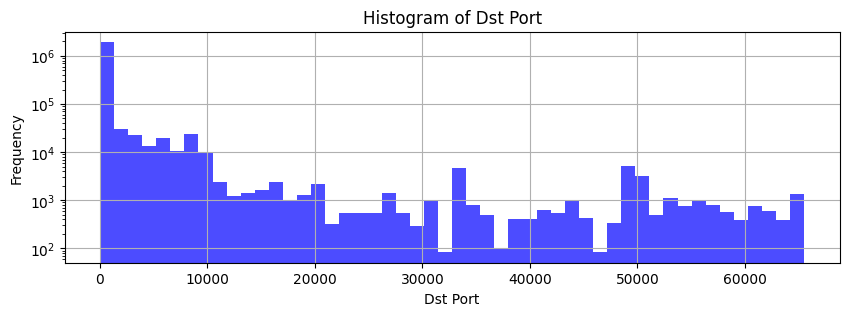

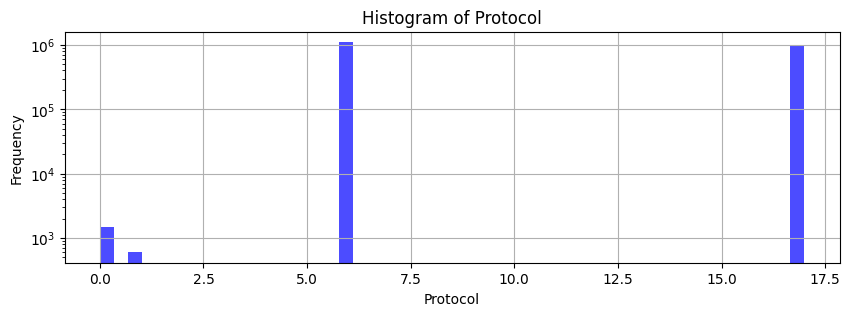

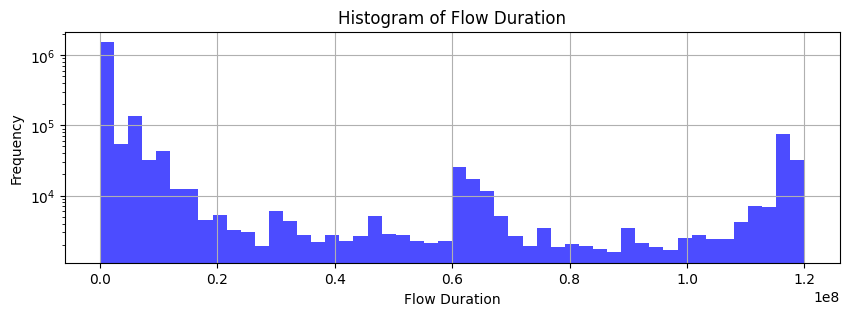

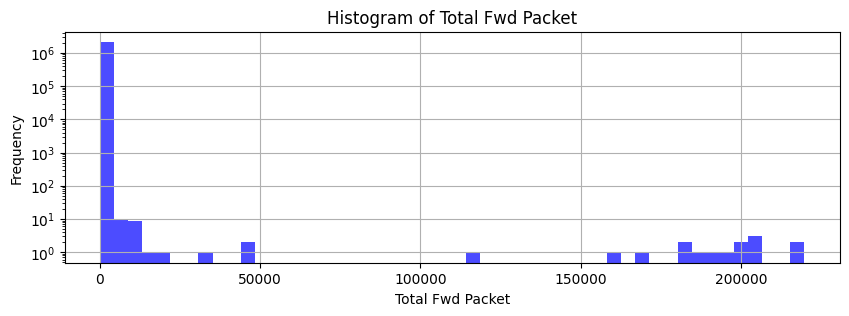

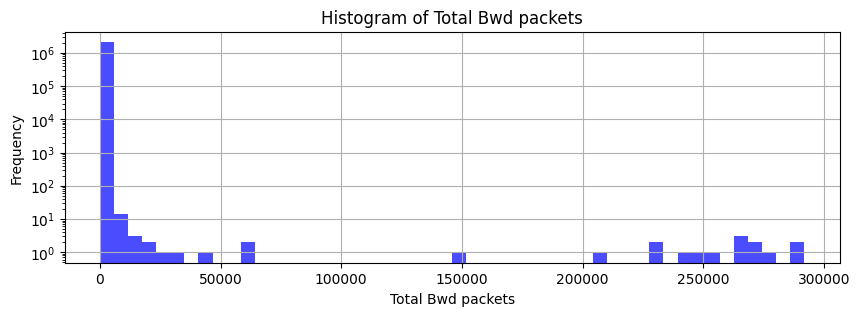

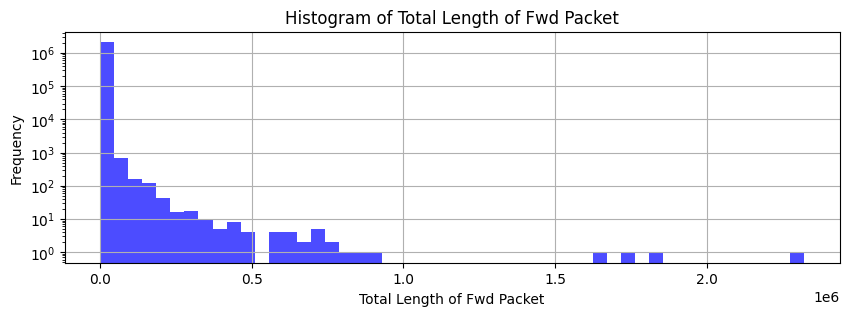

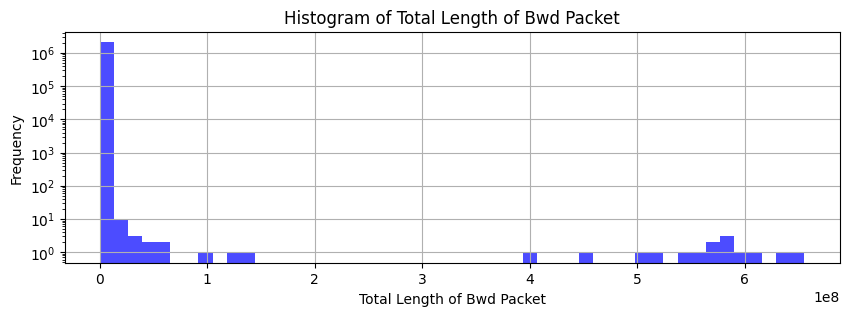

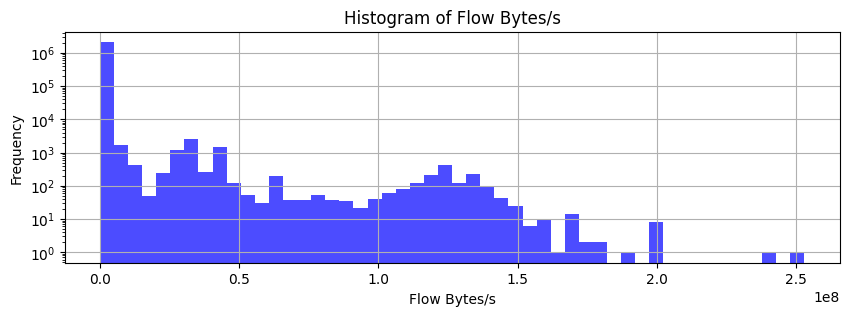

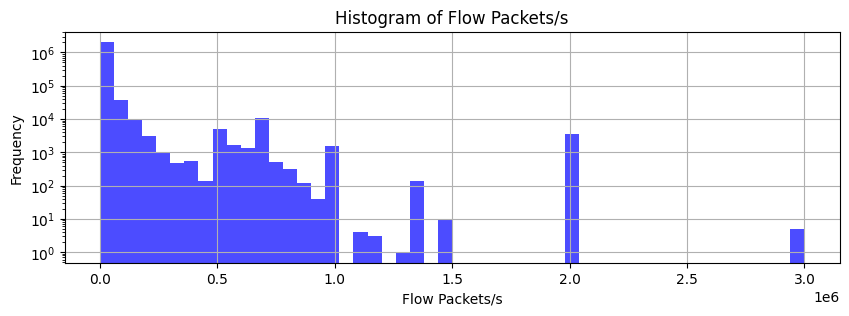

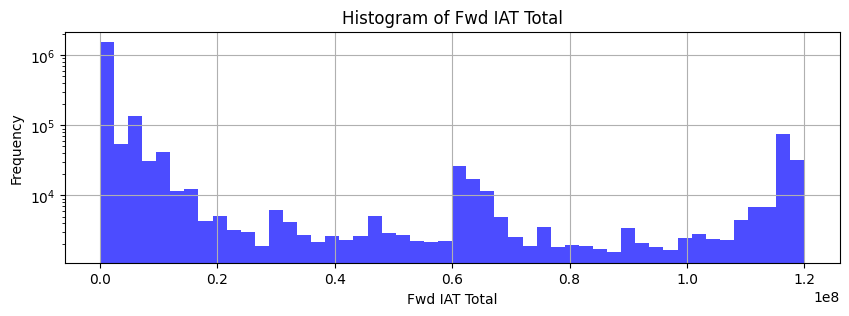

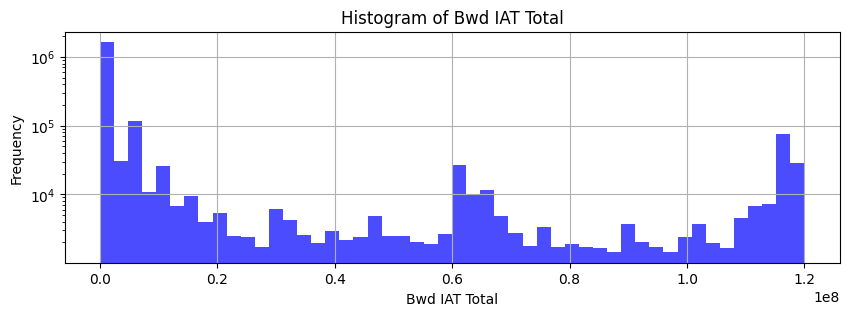

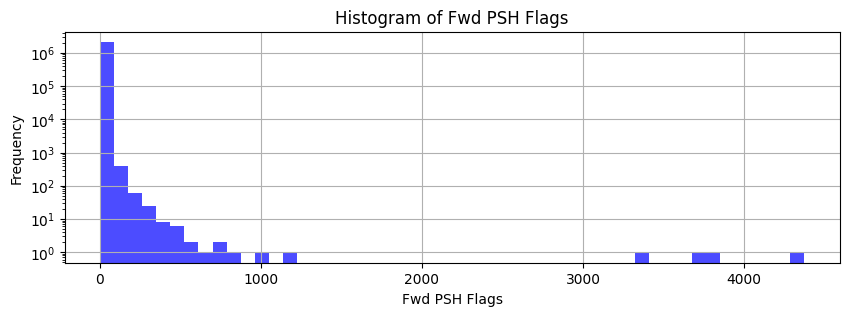

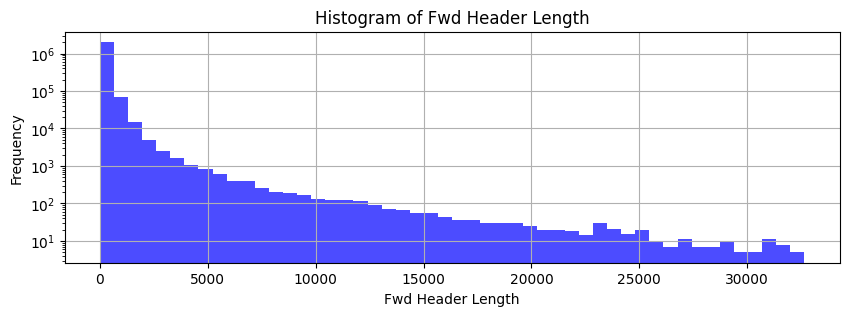

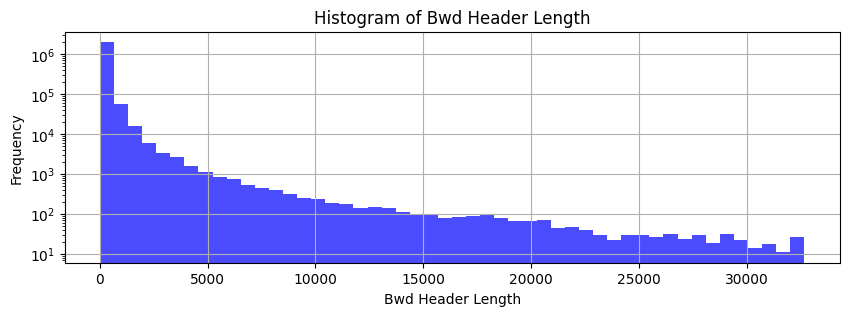

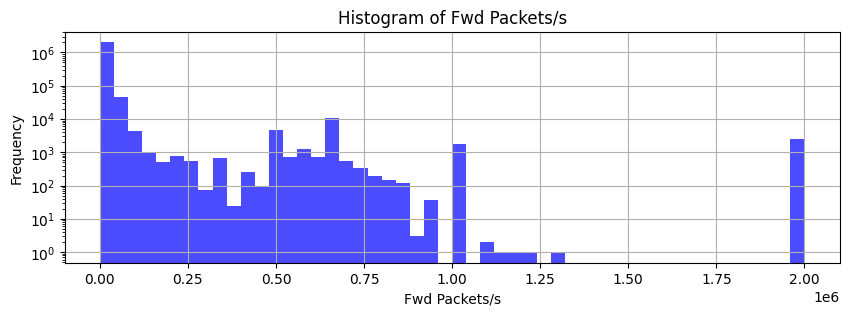

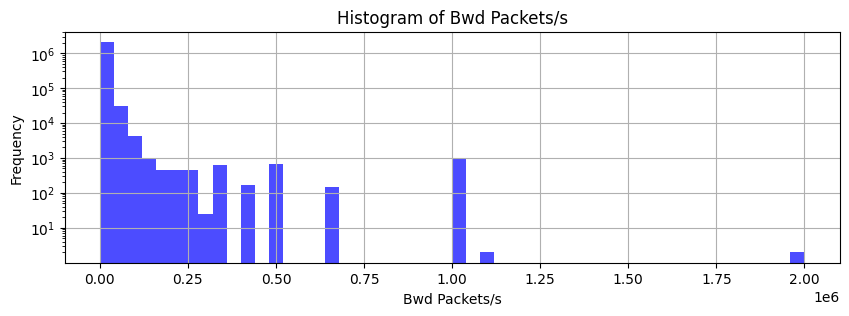

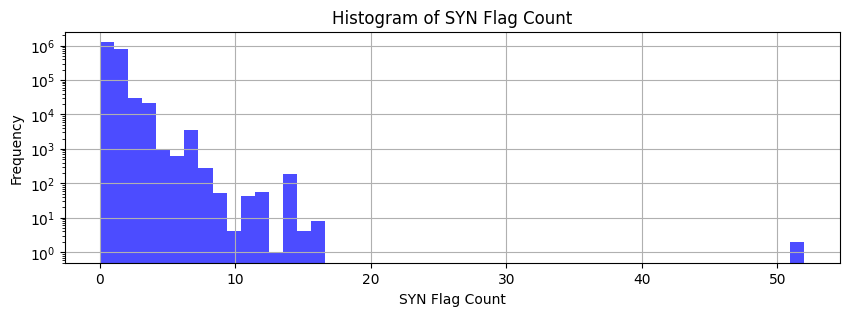

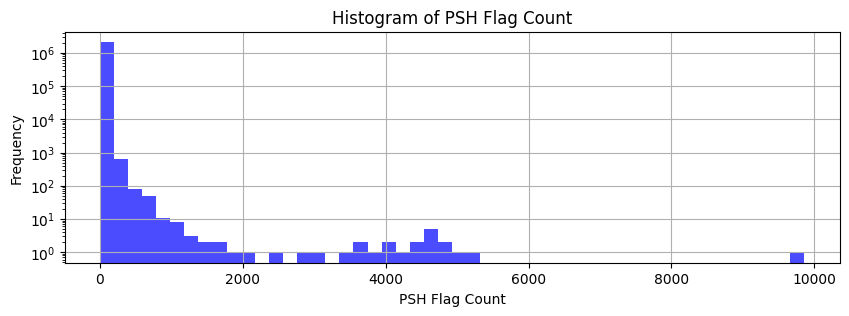

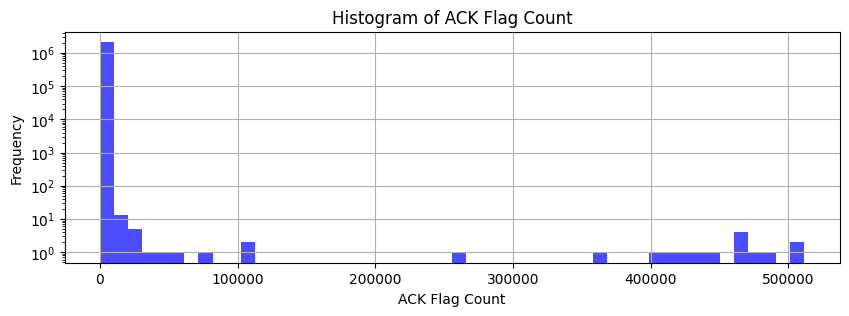

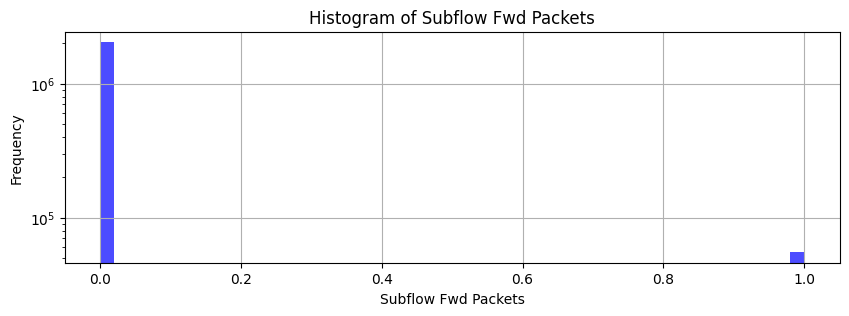

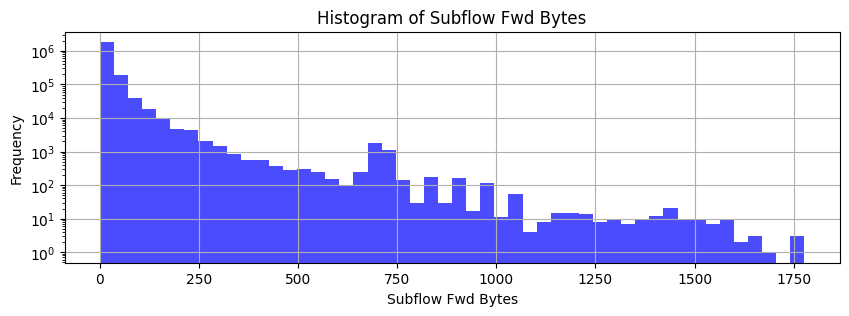

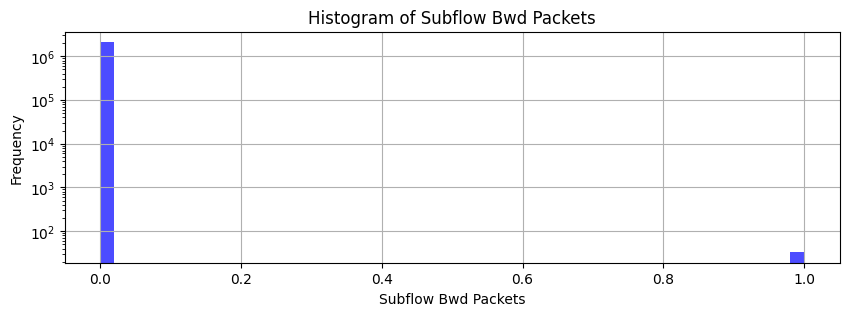

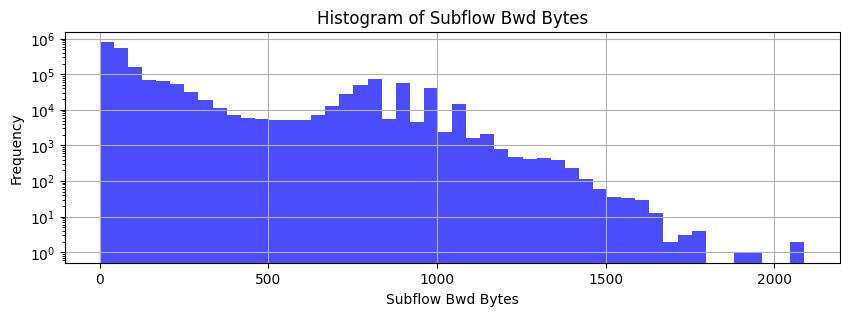

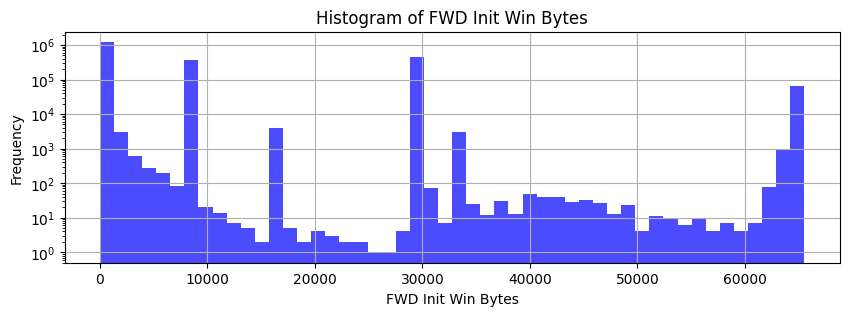

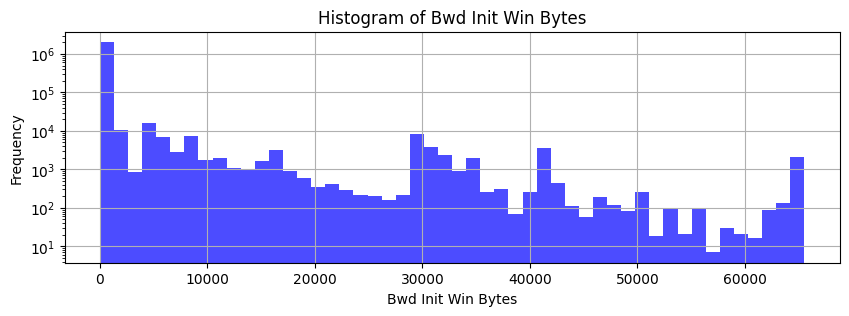

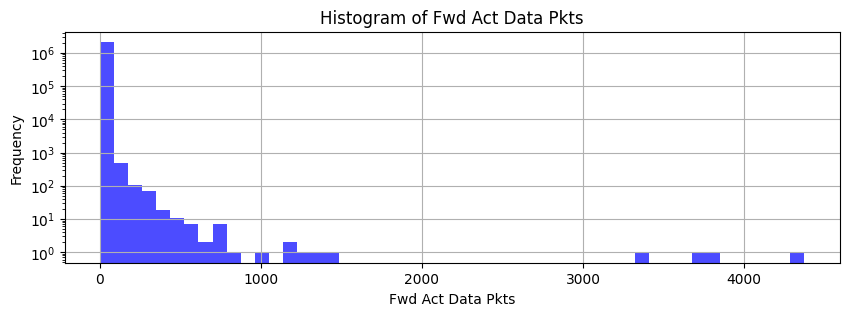

In [5]:
import matplotlib.pyplot as plt

# １つずつ特徴量をプロットして確認(log scale)
for column in df.columns:
    if column == "Label":
        continue
    plt.figure(figsize=(10, 3))
    plt.hist(df[column].dropna(), bins=50, color='blue', alpha=0.7)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.yscale('log')
    plt.grid(True)
    plt.show()



/var/folders/d3/7m94kh9j1xg5sc7cx2lk48t00000gn/T/ipykernel_74520/681143809.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df["Label"].value_counts().index, y=df["Label"].value_counts().values, palette="viridis", ax=ax)


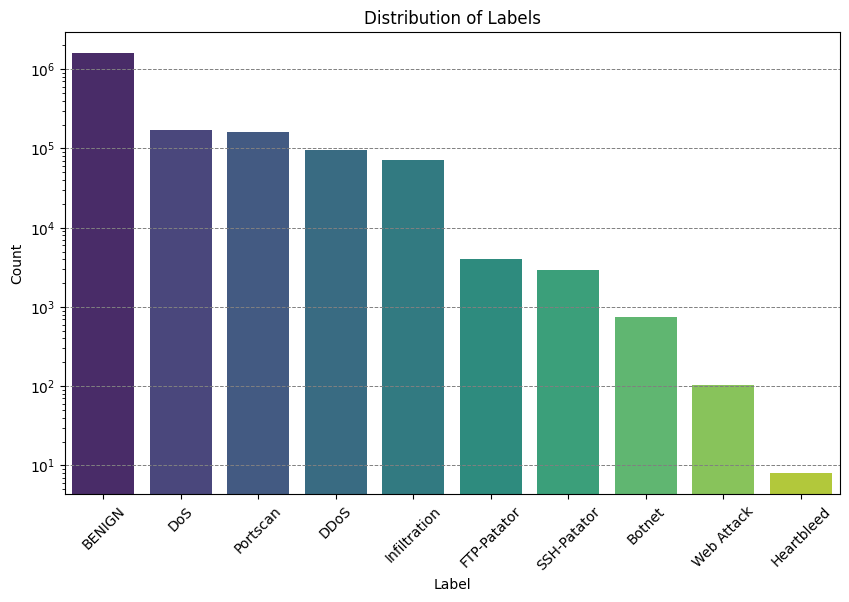

In [6]:
labels = df["Label"].unique()
import seaborn as sns

for label in labels:
    if "Attempted" in label:
        df.loc[df["Label"] == label, "Label"] = "BENIGN"
    if "Web Attack" in label:
        df.loc[df["Label"] == label, "Label"] = "Web Attack"
    if "Infiltration" in label:
        df.loc[df["Label"] == label, "Label"] = "Infiltration"
    if "DoS" in label and label != "DDoS":
        df.loc[df["Label"] == label, "Label"] = "DoS"

# label distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.barplot(x=df["Label"].value_counts().index, y=df["Label"].value_counts().values, palette="viridis", ax=ax)
ax.set_title("Distribution of Labels")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.set_yscale('log')
plt.xticks(rotation=45)
plt.grid(True, axis='y', color='gray', linestyle='--', linewidth=0.7)
plt.show()